In [1]:
# from B_1_NY2 import *
# from C_NN import *
# from B_1_extensions import (
#     VI_Brownian_MMD,
#     MMD_multiscale_median,
# )
# 
import copy
from a_NN_Samplers_and_VI_algo import * 

# Data points

In [2]:
x_data = np.linspace(-2, 12, 10, dtype=np.float64)

y_data = np.sin((2/3)*x_data + 2) + np.cos(x_data)

# with removed
# mask = np.ones(len(x_data), dtype=bool)
# mask[[3, 4]] = False
# 
# x_data = x_data[mask]
# y_data = y_data[mask]

x_mean, x_std = x_data.mean(), x_data.std()
y_mean, y_std = y_data.mean(), y_data.std()

x_data_n = (x_data - x_mean) / x_std
y_data_n = (y_data - y_mean) / y_std

x_tensor = torch.from_numpy(x_data_n).view(-1, 1)
y_tensor = torch.from_numpy(y_data_n).view(-1, 1)

x_grid_np = np.linspace(-10, 20, 1000, dtype=np.float64)
x_grid_n  = (x_grid_np - x_mean) / x_std
x_grid_tensor = torch.from_numpy(x_grid_n).view(-1, 1)  

In [3]:
x_mean, x_std, y_mean, y_std

(np.float64(5.0),
 np.float64(4.467993169529578),
 np.float64(0.18641650550194155),
 np.float64(0.9892528121208781))

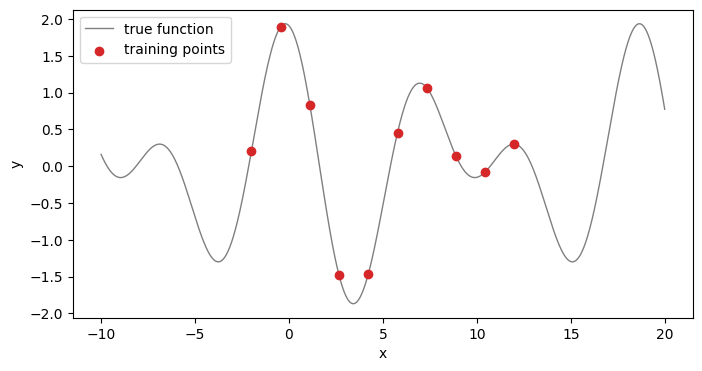

In [4]:
y_grid_true = np.sin((2/3)*x_grid_np + 2) + np.cos(x_grid_np) 

plt.figure(figsize=(8, 4))
plt.plot(x_grid_np, y_grid_true, 'k-', lw=1, alpha=0.5, label='true function')
plt.scatter(x_data, y_data, color='C3', zorder=3, label='training points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [5]:
activation_func = "tanh" # "silu"
N_hidden = 16
N_hidden2 = 16
N_sample = 100
BM_walk_len = 50
BM_step_size = 1e-4 
G_init_sigma = 0.1
covariance = "full" 

model = Net_2_Layer(N_hidden, N_hidden2 , activation_type = activation_func).double()

model_VI = NeuralNetworkModel([1, N_hidden, N_hidden2, 1], activation_type = activation_func)

dim = model_VI.theta_dim
loss_fn = Losses_SSE(model_VI, x_data_n, y_data_n)
#loss_fn = Losses_MSE(model_VI, x_data_n, y_data_n)
metric = RiemannianMetric(loss_fn)
ratio_net = RatioNet(dim).to(dtype=torch.float64) 

np.random.seed(40)
torch.manual_seed(40)
theta = Train_Net(model, 20000, x_tensor, y_tensor, lr=0.001)

sampler = Brownian_sampler(metric, walk_len=BM_walk_len, step_size = BM_step_size, n_samples=N_sample)
G_sampler = Gaussian_sampler(dim=dim, n_samples=N_sample, init_mu=theta.detach().clone(), init_sigma=G_init_sigma, covariance_type=covariance, dtype=torch.float64)

with torch.no_grad():
    predicted = model(x_grid_tensor).numpy() * y_std + y_mean

step [20000/20000], Loss: 0.0000


In [6]:
import copy
from functools import partial

n_opt_steps = 200
lr_VI       = 1e-2
beta_G      = 0.01
beta_BM     = 50.0 # 5.0
seed        = 0
sigma_G     = 0.1

sgd_lr       = lr_VI          
sgd_momentum = 0.0         

mmd_scales = (0.25, 0.5, 1.0, 2.0, 4.0)
mmd_fn     = partial(MMD_multiscale_median, scales=mmd_scales)

mu_start_G  = theta.detach().clone()
mu_start_BM = theta.detach().clone()

print("=== Gaussian VI diag ===")
sampler_G, mu_hist_G, sigma_hist_G, obj_G, exp_G, kl_G = VI_Gaussian(
    mu_start_G,
    loss_fn,
    n_samples=N_sample,
    n_opt_steps=n_opt_steps,
    lr_VI=lr_VI,
    beta=beta_G, #beta_G/10,
    sigma_p=1.0,
    init_sigma=sigma_G,
    seed=seed,
    covariance_type="diag",
    lr_mu=1e-3, # 1e-3,
    lr_rho=1e-3 # 1e-3,
    )

print("=== Gaussian VI full ===")
sampler_G_full, mu_hist_G_full, sigma_hist_G_full, obj_G_full, exp_G_full, kl_G_full = VI_Gaussian(
    mu_start_G, loss_fn,
    n_samples=N_sample, n_opt_steps=n_opt_steps,
    beta=beta_G, #beta_G/10, 
    sigma_p=1.0, init_sigma=sigma_G,
    seed=seed, covariance_type="full",
    lr_mu=1e-3, # 1e-3,
    lr_rho=1e-3, # 1e-3,
    lr_Aoff=1e-4  # 1e-4,
)

=== Gaussian VI diag ===
iter   10 | obj=8.672905 | E[L]=2.466955 | KL=620.595052 | ||mu||=9.120 | mean(sigma)=0.1004 | cov=diag
iter   20 | obj=8.790323 | E[L]=2.599693 | KL=619.062919 | ||mu||=9.103 | mean(sigma)=0.1009 | cov=diag
iter   30 | obj=8.383507 | E[L]=2.208361 | KL=617.514655 | ||mu||=9.084 | mean(sigma)=0.1013 | cov=diag
iter   40 | obj=8.223703 | E[L]=2.064624 | KL=615.907854 | ||mu||=9.065 | mean(sigma)=0.1018 | cov=diag
iter   50 | obj=8.887673 | E[L]=2.745151 | KL=614.252239 | ||mu||=9.043 | mean(sigma)=0.1023 | cov=diag
iter   60 | obj=8.720916 | E[L]=2.594386 | KL=612.653057 | ||mu||=9.023 | mean(sigma)=0.1028 | cov=diag
iter   70 | obj=8.297127 | E[L]=2.186603 | KL=611.052307 | ||mu||=9.005 | mean(sigma)=0.1033 | cov=diag
iter   80 | obj=8.423030 | E[L]=2.328244 | KL=609.478584 | ||mu||=8.988 | mean(sigma)=0.1037 | cov=diag
iter   90 | obj=8.408622 | E[L]=2.329056 | KL=607.956576 | ||mu||=8.974 | mean(sigma)=0.1042 | cov=diag
iter  100 | obj=8.470509 | E[L]=2.40664

In [7]:
print("=== Brownian VI (multi-scale median MMD, SGD) ===")
mu_BM, mu_hist_BM, obj_BM, exp_BM, kl_BM = VI_Brownian_MMD(
    mu_start_BM,
    loss_fn,
    sampler,
    mmd_fn=mmd_fn,
    mmd_label="MMD-multi-median",
    n_opt_steps=n_opt_steps,
    lr_VI=sgd_lr,
    beta=beta_BM,                    
    optimizer="sgd",
    sgd_momentum=sgd_momentum,
    seed=seed,
    drift=False,
)

=== Brownian VI (multi-scale median MMD, SGD) ===
  [diag] ||∇MMD|| = 1.325e-02, ||∇E[L]|| = 2.848e+00, ratio = 2.15e+02
  [MMD-multi-median | sgd] iter   20 | obj=20.8769 | E[L]=0.9029 | MMD=3.9948e-01 | ||mu||=9.006
  [MMD-multi-median | sgd] iter   40 | obj=20.6545 | E[L]=0.8854 | MMD=3.9538e-01 | ||mu||=8.884
  [MMD-multi-median | sgd] iter   60 | obj=20.7784 | E[L]=0.8836 | MMD=3.9790e-01 | ||mu||=8.768


KeyboardInterrupt: 

In [ ]:
def posterior_predictive(model_VI, mu, sampler, x_grid_tensor, drift=False):
    theta_samples = sampler.sample_q_endpoints(
        mu, detach_from_mu=True, drift=drift
    )
    with torch.no_grad():
        y_samples = model_VI.forward_theta_batch(theta_samples, x_grid_tensor)
    y_mean = y_samples.mean(dim=0).cpu().numpy()
    y_std  = y_samples.std(dim=0).cpu().numpy()
    return y_samples.cpu().numpy(), y_mean, y_std

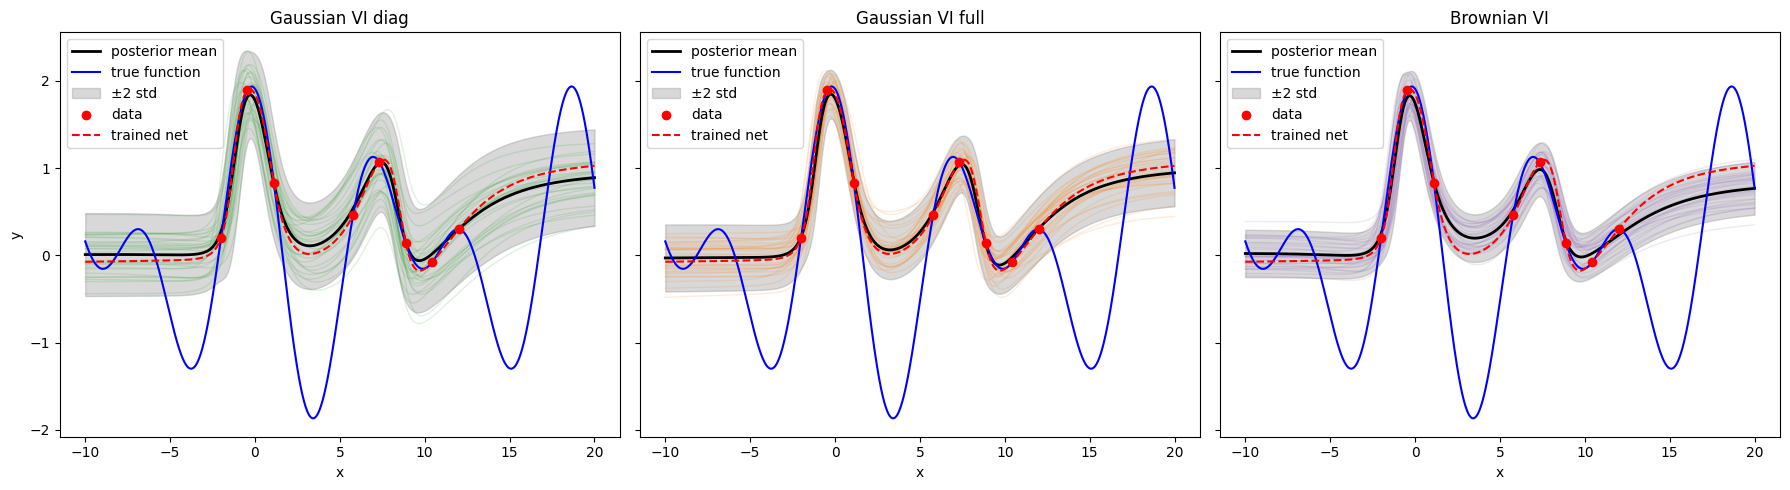

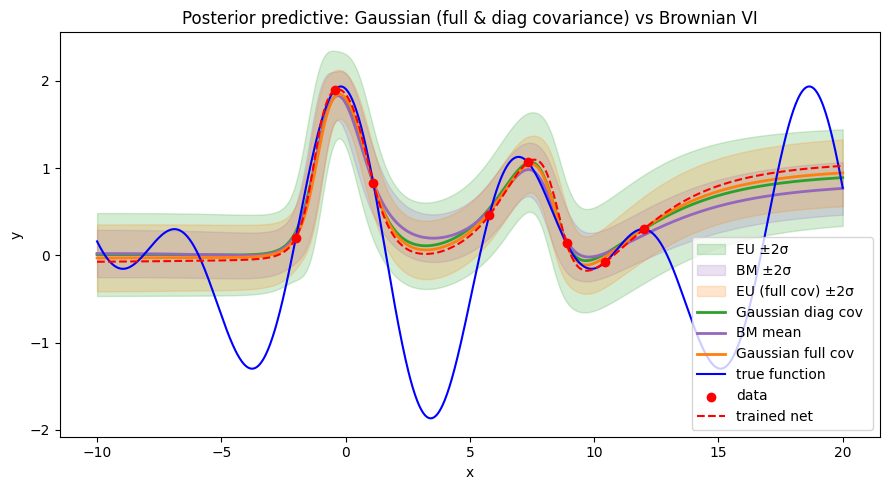

In [ ]:
y_s_G_n,  m_G_n,  s_G_n  = posterior_predictive(model_VI, sampler_G.mu, sampler_G, x_grid_tensor)
m_G = m_G_n * y_std + y_mean
s_G = s_G_n * y_std            
y_s_G = y_s_G_n * y_std + y_mean

y_s_Gf_n, m_Gf_n, s_Gf_n = posterior_predictive(model_VI, sampler_G_full.mu, sampler_G_full, x_grid_tensor)
m_Gf = m_Gf_n * y_std + y_mean
s_Gf = s_Gf_n * y_std
y_s_Gf = y_s_Gf_n * y_std + y_mean

y_s_BM_n, m_BM_n, s_BM_n = posterior_predictive(model_VI, mu_BM, sampler, x_grid_tensor)
m_BM = m_BM_n * y_std + y_mean
s_BM = s_BM_n * y_std
y_s_BM = y_s_BM_n * y_std + y_mean


xg = x_grid_np
n_show = 30

y_true = np.sin((2/3)*xg + 2) + np.cos(xg)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (title, y_s, m, s, col) in zip(
    axes,
    [("Gaussian VI diag",  y_s_G,  m_G,  s_G,  "tab:green"),
     ("Gaussian VI full",  y_s_Gf,  m_Gf,  s_Gf,  "tab:orange"),
     ("Brownian VI",   y_s_BM, m_BM, s_BM, "tab:purple")],
):
    for i in range(min(n_show, y_s.shape[0])):
        ax.plot(xg, y_s[i], color=col, alpha=0.15, lw=1)
    ax.plot(xg, m, color="black", lw=2, label="posterior mean")
    ax.plot(xg, y_true, color="blue", lw=1.5, ls="-", label="true function")
    ax.fill_between(xg, m - 2*s, m + 2*s, color="gray", alpha=0.3, label="±2 std")
    ax.scatter(x_data, y_data, color="red", zorder=5, label="data")
    ax.plot(xg, predicted, color="red", lw=1.5, ls="--", label="trained net")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.legend()
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.fill_between(xg, m_G - 2*s_G, m_G + 2*s_G,
                 color="tab:green", alpha=0.20, label="EU ±2σ")
plt.fill_between(xg, m_BM - 2*s_BM, m_BM + 2*s_BM,
                 color="tab:purple", alpha=0.20, label="BM ±2σ")
plt.fill_between(xg, m_Gf - 2*s_Gf, m_Gf + 2*s_Gf,
                 color="tab:orange", alpha=0.20, label="EU (full cov) ±2σ")
plt.plot(xg, m_G, color="tab:green",  lw=2, label="Gaussian diag cov ")
plt.plot(xg, m_BM, color="tab:purple", lw=2, label="BM mean")
plt.plot(xg, m_Gf, color="tab:orange",  lw=2, label="Gaussian full cov")
plt.plot(xg, y_true, color="blue", lw=1.5, ls="-", label="true function")
plt.scatter(x_data, y_data, color="red", zorder=5, label="data")
plt.plot(xg, predicted, color="red", lw=1.5, ls="--", label="trained net")
plt.title("Posterior predictive: Gaussian (full & diag covariance) vs Brownian VI")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()